# EX04: Lexical Analysis

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho

(Some exercises originally by José Carlos Ramalho)

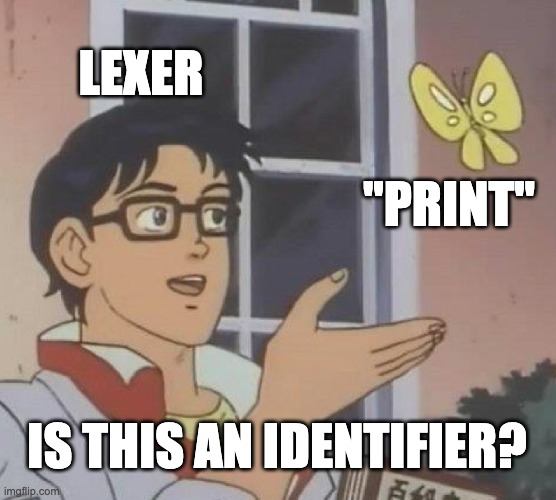

# Generation of Lexers

Consider the following (simple) lexer generator that is written into a `generator.py` Python script when the cell is executed.

Given a JSON file with token descriptions, it generates a lexer as another Python script, and sends it to the standard output.

The lexer has two special token names:
  - `IGNORE` is reserved for tokens that are to be discarded
  - `NEWLINE` is reserved for line counting, and is also discarded

Moreover, the token `UNKNOWN` is assigned to any symbol that does not match any of the defined tokens.

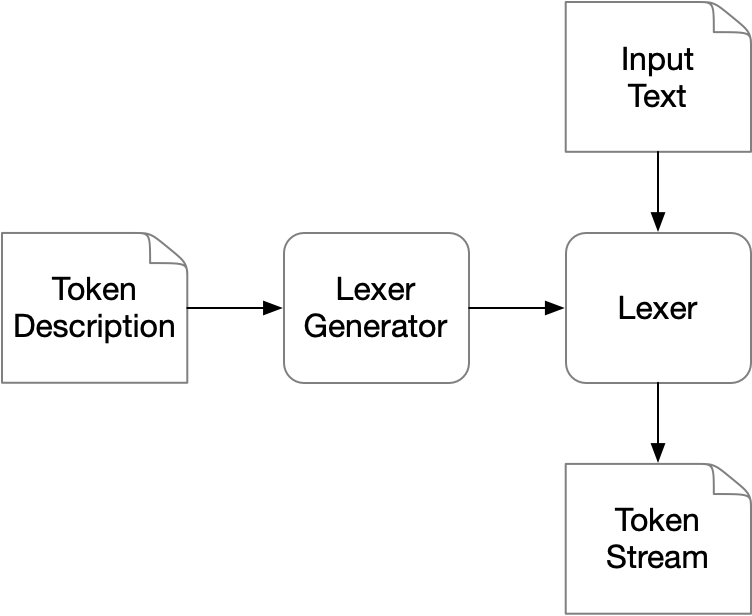

⚠️ In a Jupyter notebook, instruction `%%writefile` sends the content of a cell into a file.

In [ ]:
%%writefile generator.py
import sys
import json

def generate(token_file):
  with open(token_file, "r") as f:
    token_dict = json.load(f)

  if "UNKNOWN" in token_dict:
    print("Reserved token name UNKNOWN")
    return

  regex = ("|".join(f"(?P<{token}>{pattern})" for token, pattern in token_dict.items()))+"|(?P<UNKNOWN>.)"
  code = f"""import re
import sys
def tokenize(line):
  line_num = 1
  recognized = []
  errors = []
  for mtch in re.finditer(r"{regex}",line):
    for k,v in mtch.groupdict().items():
      if v != None:
        token = (k, v, line_num, mtch.start())
        break

    if token[0] == "NEWLINE":
      line_num += token[1].count("\\n")
    elif token[0] == "UNKNOWN":
        errors.append(token)
    elif token[0] != "IGNORE":
        recognized.append(token)
  return recognized, errors

def main():
  toks, errs = tokenize(sys.stdin.read())
  for err in errs:
      print("Invalid symbol:", err)
  for tok in toks:
      print(tok)

if __name__ == "__main__":
    main()
"""
  print(code)

def main():
    if len(sys.argv) < 2:
        print("Usage: python generator.py <filename>")
        sys.exit(1)

    filename = sys.argv[1]

    generate(filename)

if __name__ == "__main__":
    main()

Writing generator.py


## Usage example: Arithmetic expressions

Create a JSON file associating each token name with a regular expression that defines its lexemes.

⚠️ Note that JSON does not support raw expressions, so all backslashes must be escaped.

In [ ]:
%%writefile tokens_arithmetic.json
{
    "IDEN" : "[A-Za-z]+",
    "INT" : "\\d+",
    "ADD" : "\\+",
    "MUL" : "\\*",
    "SUB" : "-",
    "DIV" : "/",
    "LPAREN" : "\\(",
    "RPAREN" : "\\)",
    "IGNORE" : "[ \\t]+",
    "NEWLINE" : "\\n"
}

Writing tokens_arithmetic.json


Call the lexer generator (`generator.py`) with this JSON token description file (`tokens_arithmetic.json`) and create the Python lexer in a new file (`lexer_arithmetic.py`). This file tokenizes a text file provided through the standard input.

In [ ]:
!python generator.py tokens_arithmetic.json > lexer_arithmetic.py
!cat lexer_arithmetic.py

import re
import sys
def tokenize(line):
  line_num = 1
  recognized = []
  errors = []
  for mtch in re.finditer(r"(?P<IDEN>[A-Za-z]+)|(?P<INT>\d+)|(?P<ADD>\+)|(?P<MUL>\*)|(?P<SUB>-)|(?P<DIV>/)|(?P<LPAREN>\()|(?P<RPAREN>\))|(?P<IGNORE>[ \t]+)|(?P<NEWLINE>\n)|(?P<UNKNOWN>.)",line):
    for k,v in mtch.groupdict().items():
      if v != None:
        token = (k, v, line_num, mtch.start())
        break

    if token[0] == "NEWLINE":
      line_num += token[1].count("\n")
    elif token[0] == "UNKNOWN":
        errors.append(token)
    elif token[0] != "IGNORE":
        recognized.append(token)
  return recognized, errors

def main():
  toks, errs = tokenize(sys.stdin.read())
  for err in errs:
      print("Invalid symbol:", err)
  for tok in toks:
      print(tok)

if __name__ == "__main__":
    main()



Then, create a file with the input text you want to tokenize (`example_arithmetic.txt`), and call the lexer (`lexer_arithmetic.py`).

In [ ]:
%%writefile example_arithmetic.txt
10 * x + (34 / yz)

Writing example_arithmetic.txt


In [ ]:
!python lexer_arithmetic.py < example_arithmetic.txt

('INT', '10', 1, 0)
('MUL', '*', 1, 3)
('IDEN', 'x', 1, 5)
('ADD', '+', 1, 7)
('LPAREN', '(', 1, 9)
('INT', '34', 1, 10)
('DIV', '/', 1, 13)
('IDEN', 'yz', 1, 15)
('RPAREN', ')', 1, 17)


Alternatively, you can also import the lexer module and call the `tokenize()` function directly.

In [ ]:
from lexer_arithmetic import tokenize

with open("example_arithmetic.txt", "r") as f:
  ex = f.read()

tokens, errors = tokenize(ex)
print(tokens)

[('INT', '10', 1, 0), ('MUL', '*', 1, 3), ('IDEN', 'x', 1, 5), ('ADD', '+', 1, 7), ('LPAREN', '(', 1, 9), ('INT', '34', 1, 10), ('DIV', '/', 1, 13), ('IDEN', 'yz', 1, 15), ('RPAREN', ')', 1, 17)]


## Exercise 1

For each of the languages presented below, write a JSON file with token definitions, and generate the corresponding lexer.

In [ ]:
import doctest

### Exercise 1.1

A language consisting only of balanced parenthesis.

- `()` ✅
- `()(())` ✅
- `[()()]` ❌ (lexical error)


In [ ]:
%%writefile tokens_parenthesis.json
{

}

Writing tokens_parenthesis.json


In [ ]:
!python generator.py tokens_parenthesis.json > lexer_parenthesis.py

In [ ]:
import lexer_parenthesis
# force reload if lexer file was regenerated
import importlib
importlib.reload(lexer_parenthesis)

def tokenize_parenthesis(text):
  r"""
  >>> tokenize_parenthesis("()(())")[0][0]
  ('LPAREN', '(', 1, 0)

  >>> tokenize_parenthesis("()(())")[0][4]
  ('RPAREN', ')', 1, 4)

  >>> tokenize_parenthesis("[(())())]")[1][0]
  ('UNKNOWN', '[', 1, 0)

  >>> tokenize_parenthesis("[(())())]")[0][1]
  ('LPAREN', '(', 1, 2)
  """
  return lexer_parenthesis.tokenize(text)

doctest.run_docstring_examples(tokenize_parenthesis, globals())

### Exercise 1.2

A language to represent of binary trees with integer values.

- `(5 (22 () ()) (9 () (17 () ())))` ✅
- `(25 () ())` ✅
- `(57 (xy () ()) ())` ❌ (lexical error)

In [ ]:
%%writefile tokens_bintree.json
{

}

Writing tokens_bintree.json


In [ ]:
!python generator.py tokens_bintree.json > lexer_bintree.py

In [ ]:
import lexer_bintree
# force reload if lexer file was regenerated
import importlib
importlib.reload(lexer_bintree)

def tokenize_bintree(text):
  r"""
  >>> tokenize_bintree("(5 (22 () ()) (9 () (17 () ())))")[0][0]
  ('LPAREN', '(', 1, 0)

  >>> tokenize_bintree("(5 (22 () ()) (9 () (17 () ())))")[0][3]
  ('VAL', '22', 1, 4)

  >>> tokenize_bintree("(5 (22 () ()) (9 () (17 () ())))")[1]
  []

  >>> tokenize_bintree("(57 (xy () ()) ())")[1][0]
  ('UNKNOWN', 'x', 1, 5)

  >>> tokenize_bintree("(57 (xy () ()) ())")[0][4]
  ('RPAREN', ')', 1, 9)
  """
  return lexer_bintree.tokenize(text)

doctest.run_docstring_examples(tokenize_bintree, globals())

### Exercise 1.3

A language to present propositional logic formulas, with propositional variables defined in a header.

```
var AB, XY;
var prop;
AB \/ XY /\ True => (AB \/ !prop)  ✅
```

```
var A.
A /\ True  ❌ (lexical error)
```


In [ ]:
%%writefile tokens_proplogic.json
{

}

Writing tokens_proplogic.json


In [ ]:
!python generator.py tokens_proplogic.json > lexer_proplogic.py

In [ ]:
import lexer_proplogic
# force reload if lexer file was regenerated
import importlib
importlib.reload(lexer_proplogic)

ex1 = r"""
var AB, XY;
var prop;
AB \/ XY /\ True => (AB \/ !prop)
"""

ex2 = r"""
var A.
A /\ True
"""

def tokenize_proplogic(text):
  r"""
  >>> tokenize_proplogic(ex1)[0][0]
  ('VAR', 'var', 2, 1)

  >>> tokenize_proplogic(ex1)[0][2]
  ('COLON', ',', 2, 7)

  >>> tokenize_proplogic(ex1)[0][3]
  ('IDEN', 'XY', 2, 9)

  >>> tokenize_proplogic(ex1)[0][12]
  ('TRUE', 'True', 4, 35)

  >>> tokenize_proplogic(ex1)[0][13]
  ('IMPLIES', '=>', 4, 40)

  >>> tokenize_proplogic(ex1)[0][16]
  ('OR', '\\/', 4, 47)

  >>> tokenize_proplogic(ex1)[0][18]
  ('IDEN', 'prop', 4, 51)

  >>> tokenize_proplogic(ex2)[1][0]
  ('UNKNOWN', '.', 2, 6)
  """
  return lexer_proplogic.tokenize(text)

doctest.run_docstring_examples(tokenize_proplogic, globals())

### Exercise 1.4

The [SQL](https://en.wikipedia.org/wiki/SQL) language use to manage data in relational databases. Consider the following SQL instructions as examples.

```sql
CREATE TABLE users (
  id INTEGER PRIMARY KEY,
  name TEXT,
  age INTEGER
);
```

```sql
INSERT INTO users (name, age) VALUES ('Jane Doe', 'Yes');
```

```sql
SELECT name FROM users WHERE age > 25;
```

In [ ]:
%%writefile tokens_sql.json
{

}

Writing tokens_sql.json


In [ ]:
!python generator.py tokens_sql.json > lexer_sql.py

In [ ]:
import lexer_sql
# force reload if lexer file was regenerated
import importlib
importlib.reload(lexer_sql)

ex1 = r"""
CREATE TABLE users (
  id INTEGER PRIMARY KEY,
  name TEXT,
  age INTEGER
);
"""
ex2 = r"INSERT INTO users (name, active) VALUES ('Jane Doe', 'Yes');"
ex3 = r"SELECT name FROM users WHERE age > 25;"

def tokenize_sql(text):
  """
  >>> tokenize_sql(ex1)[0][0]
  ('CREATE', 'CREATE', 2, 1)

  >>> tokenize_sql(ex1)[0][4]
  ('IDEN', 'id', 3, 24)

  >>> tokenize_sql(ex1)[0][8]
  ('COMMA', ',', 3, 46)

  >>> tokenize_sql(ex2)[0][10]
  ('STR', "'Jane Doe'", 1, 41)

  >>> tokenize_sql(ex2)[0][12]
  ('STR', "'Yes'", 1, 53)

  >>> tokenize_sql(ex3)[0][5]
  ('IDEN', 'age', 1, 29)

  >>> tokenize_sql(ex3)[0][6]
  ('GT', '>', 1, 33)
  """
  return lexer_sql.tokenize(text)

doctest.run_docstring_examples(tokenize_sql, globals())

# Generating Lexers with `Ply`



## Module [`Ply`](https://ply.readthedocs.io/) basics

- A Python implementation of the popular `lex`/`yacc` compiler front-end tools

- The lexical and syntactical analysis phases are distinct:
  - The lexer definition is given as a set of regular expressions that represent different token categories
  - The parser definition is given as a grammar in BNF whose terminal symbols are token categories

- In traditional `lex`/`yacc`, the specifications are given as separate files and compiled into a target language
  - In `Ply` they are written directly in Python (uses reflection)


In [ ]:
!pip install Ply
__file__ = "Untitled.ipynb" # needed to run PLY inside notebook

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.8 MB/s eta 0:00:00


⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module
  - This leads to some conflicts when writing specifications in notebooks, which is not recommended
  - Either run the code outside the notebook, restart the notebook session if it becomes corrupted, or run the following function to clean all defined `Ply` identifiers


In [ ]:
def cleanLexGlobals():
  "Remove ply.lex identifiers from the global context."
  for t in [n for n in globals() if n.startswith("t_") or n in ("tokens", "literals", "states")]:
    del globals()[t]

## [`Ply.lex`](https://ply.readthedocs.io/en/latest/ply.html#lex) basics

- The list of token names is given in a variable `tokens`

- After tokenization, each token has a `type` and a `value` assigned (by default, the lexeme)
  - Also positions `lineno` and `lexpos`

- The pattern for each token type `T` is defined by a variable `t_T` in the Python script
  - Either directly with a string literal with a RE
  - Or through a function that has a RE as docstring and further actions to calculate its value

- Can also define single-symbol literal tokens in variable `literals` (both type and value become the symbol)

- The master RE is built in the following order:
  - Function-defined tokens by order they appear
  - Literal-defined tokens by descending length

- Other special function:
  - `t_ignore` to automatically ignore certain symbols
  - `t_newline` to track new lines
  - `t_error` to handle errors

## Usage example: Arithmetic expressions

In [ ]:
import ply.lex as lex

# list of (non-literal) token names
tokens = ('IDEN', 'INT', 'FLOAT', 'ADD', 'SUB', 'DIV', 'MUL')

# literal tokens, single symbol, name same as lexeme
literals = ('(', ')')

# literal-defined tokens follow longest regex first
t_ADD    = r'\+'
t_SUB    = r'-'
t_MUL    = r'\*'
t_DIV    = r'/'
t_IDEN   = r'[A-Za-z]+'

# function-defined tokens follow definition order
def t_FLOAT(t):
  r'\d+\.\d*|\.\d+'
  t.value = float(t.value)
  return t

def t_INT(t):
  r'\d+'
  t.value = int(t.value)
  return t

# set of symbols to ignore
t_ignore = ' \t'

# new line handler
def t_newline(t):
    r'\n'
    t.lexer.lineno += 1

# error handler
def t_error(t):
  print(f"Illegal character: {t.value[0]}")
  t.lexer.skip(1)

lexer = lex.lex()

In [ ]:
%%writefile example_arithmetic.txt
10 * x + (34 / yz)

Overwriting example_arithmetic.txt


In [ ]:
def run_lexer(text):
    lexer.input(text)
    return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

with open("example_arithmetic.txt", "r") as f:
  ex = f.read()

run_lexer(ex)

[('INT', 10, 1, 0),
 ('MUL', '*', 1, 3),
 ('IDEN', 'x', 1, 5),
 ('ADD', '+', 1, 7),
 ('(', '(', 1, 9),
 ('INT', 34, 1, 10),
 ('DIV', '/', 1, 13),
 ('IDEN', 'yz', 1, 15),
 (')', ')', 1, 17)]

## Exercise 2

For each of the languages presented in Exercise 1, write a lexer using `Ply.lex`.

### Exercise 2.1

A language consisting only of balanced parenthesis.


In [ ]:
cleanLexGlobals() # clean up previous token definitions


def tokenize_parenthesis(text):
  r"""
  >>> tokenize_parenthesis("()(())")[0]
  ('LPAREN', '(', 1, 0)

  >>> tokenize_parenthesis("()(())")[4]
  ('RPAREN', ')', 1, 4)

  >>> tokenize_parenthesis("[(())())]")[1]
  Illegal character: [
  Illegal character: ]
  ('LPAREN', '(', 1, 2)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_parenthesis, globals())

### Exercise 2.2

A language to represent of binary trees with integer values.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


def tokenize_bintree(text):
  r"""
  >>> tokenize_bintree("(5 (22 () ()) (9 () (17 () ())))")[0]
  ('(', '(', 1, 0)

  >>> tokenize_bintree("(5 (22 () ()) (9 () (17 () ())))")[3]
  ('VAL', '22', 1, 4)

  >>> tokenize_bintree("(57 (xy () ()) ())")[1]
  Illegal character: x
  Illegal character: y
  ('VAL', '57', 1, 1)

  >>> tokenize_bintree("(57 (xy () ()) ())")[4]
  Illegal character: x
  Illegal character: y
  (')', ')', 1, 9)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_bintree, globals())

### Exercise 2.3

A language to present propositional logic formulas, with propositional variables defined in a header.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


ex1 = r"""
var AB, XY;
var prop;
AB \/ XY /\ True => (AB \/ !prop)
"""

ex2 = r"""
var A.
A /\ True
"""

def tokenize_proplogic(text):
  r"""
  >>> tokenize_proplogic(ex1)[0]
  ('VAR', 'var', 2, 1)

  >>> tokenize_proplogic(ex1)[2]
  (',', ',', 2, 7)

  >>> tokenize_proplogic(ex1)[3]
  ('IDEN', 'XY', 2, 9)

  >>> tokenize_proplogic(ex1)[12]
  ('TRUE', 'True', 4, 35)

  >>> tokenize_proplogic(ex1)[13]
  ('IMPLIES', '=>', 4, 40)

  >>> tokenize_proplogic(ex1)[16]
  ('OR', '\\/', 4, 47)

  >>> tokenize_proplogic(ex1)[18]
  ('IDEN', 'prop', 4, 51)

  >>> tokenize_proplogic(ex2)[0]
  Illegal character: .
  ('VAR', 'var', 2, 1)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_proplogic, globals())

### Exercise 2.4

The [SQL](https://en.wikipedia.org/wiki/SQL) language use to manage data in relational databases.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


ex1 = r"""
CREATE TABLE users (
  id INTEGER PRIMARY KEY,
  name TEXT,
  age INTEGER
);
"""
ex2 = r"INSERT INTO users (name, active) VALUES ('Jane Doe', 'Yes');"
ex3 = r"SELECT name FROM users WHERE age > 25;"

def tokenize_sql(text):
  """
  >>> tokenize_sql(ex1)[0]
  ('CREATE', 'CREATE', 2, 1)

  >>> tokenize_sql(ex1)[4]
  ('IDEN', 'id', 3, 24)

  >>> tokenize_sql(ex1)[8]
  (',', ',', 3, 46)

  >>> tokenize_sql(ex2)[10]
  ('STR', 'Jane Doe', 1, 41)

  >>> tokenize_sql(ex2)[12]
  ('STR', 'Yes', 1, 53)

  >>> tokenize_sql(ex3)[5]
  ('IDEN', 'age', 1, 29)

  >>> tokenize_sql(ex3)[6]
  ('GT', '>', 1, 33)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_sql, globals())

## Exercise 3

Consider the [`cinema.json`](https://elearning.uminho.pt/bbcswebdav/pid-1774485-dt-content-rid-13918576_1/xid-13918576_1?xythos-download=true) file containing a JSON database of movies.

### Exercise 3.1

Write a lexer to tokenize arbitrary JSON files.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


with open("cinema.json", "r") as f:
  db = f.read()

def tokenize_json(text):
  """
  >>> tokenize_json(db)[0]
  ('[', '[', 1, 0)

  >>> tokenize_json(db)[2]
  ('STR', 'title', 2, 5)

  >>> tokenize_json(db)[8]
  ('INT', 1968, 2, 47)

  >>> tokenize_json(db)[10]
  ('STR', 'cast', 2, 53)

  >>> tokenize_json(db)[12]
  ('[', '[', 2, 61)

  >>> tokenize_json(db)[32]
  ('STR', 'year', 3, 168)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_json, globals())

FileNotFoundError: [Errno 2] No such file or directory: 'cinema.json'

### Exercise 3.2

Assume now that `cinema.json` is actually encoded in a JSON-based DSL (*domain-specific language*), where the dictionary keys are fixed and have a specific meaning. Write a tokenizer for this DSL.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


with open("cinema.json", "r") as f:
  db = f.read()

def tokenize_json(text):
  """
  >>> tokenize_json(db)[0]
  ('[', '[', 1, 0)

  >>> tokenize_json(db)[2]
  ('TITLE', '"title"', 2, 5)

  >>> tokenize_json(db)[8]
  ('INT', 1968, 2, 47)

  >>> tokenize_json(db)[10]
  ('CAST', '"cast"', 2, 53)

  >>> tokenize_json(db)[12]
  ('[', '[', 2, 61)

  >>> tokenize_json(db)[32]
  ('STR', 'year', 3, 168)
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_json, globals())

## Context conditions

- `Ply.lex` supports the definition of states and the recognition of tokens can trigger a change in state

- Start by defining the states:
  - Define the list of possible states in a variable `states`
  - There is always an implicitly defined state `INITIAL`
  - Each state can be:
    - `exclusive`: when active, only the rules for that state apply
    - `inclusive`: when active, only the rules for that state and `INITIAL` apply

- Define the rules that apply to each state:
  - Each token definition can have a set of state prefixes
    - `t_STATE_TOKENNAME` for recognizing `TOKENNAME` when `STATE` is active
  - Rules with state prefix `ANY` apply in all states
  - Rules without a state prefix refer to the `INITIAL` state (and other inclusive states)

- Define the state changes inside token recognition function:
  - Method `begin(STATE)` of the lexer activates state `STATE`

## Exercise 4

Consider an interactive calculator with the following commands:

 -  `! e` - print the value of an expression `e`
 -  `? v` - ask the user for a value for variable `v`
 -  `v = e` - assign value of expression `e` to variable `v`
 -  `*` - dump to the ouput the value of all variables
 -  `#` - close the calculator

### Exercise 4.1

Write a tokenizer for a single command for the interactive calculator.

In [ ]:
cleanLexGlobals() # clean up previous token definitions


def tokenize_calc(text):
  """
  >>> tokenize_calc("! x + 10")
  [('EXCLAMATION', '!', 1, 0), ('IDEN', 'x', 1, 2), ('ADD', '+', 1, 4), ('INT', 10, 1, 6)]

  >>> tokenize_calc("? x")
  [('QUESTION', '?', 1, 0), ('IDEN', 'x', 1, 2)]

  >>> tokenize_calc("x = y * 20")
  [('IDEN', 'x', 1, 0), ('EQ', '=', 1, 2), ('IDEN', 'y', 1, 4), ('MUL', '*', 1, 6), ('INT', 20, 1, 8)]

  >>> tokenize_calc("*")
  [('STAR', '*', 1, 0)]

  >>> tokenize_calc("! ! x + 10")
  Illegal character: !
  [('EXCLAMATION', '!', 1, 0), ('IDEN', 'x', 1, 4), ('ADD', '+', 1, 6), ('INT', 10, 1, 8)]

  >>> tokenize_calc("? x + 5")
  Illegal character: +
  Illegal character: 5
  [('QUESTION', '?', 1, 0), ('IDEN', 'x', 1, 2)]

  >>> tokenize_calc("* 7")
  Illegal character: 7
  [('STAR', '*', 1, 0)]
  """
  lexer = lex.lex()
  lexer.input(text)
  return [(tok.type, tok.value, tok.lineno, tok.lexpos) for tok in lexer]

doctest.run_docstring_examples(tokenize_calc, globals())

### Exercise 4.2

Create an interactive program that iteratively processes commands from the standard input.

## Exercise 5

Use a lexer to create a conditional summing program. This program should receive an arbitrary text, and sum all the integers numbers within it. However, it stops summing when it finds the word `OFF`, and only restarts summing again once the word `ON` appears. These keywords are *not* case sensitive. Whenever the program finds the symbol `=`, it should print the current sum into the output.


In [ ]:
cleanLexGlobals() # clean up previous token definitions


def sumOnOff(text):
  """
  >>> sumOnOff("Contas: 10, 20 =")
  30

  >>> sumOnOff("Contas: 15, 20; = off! 29 30... =?")
  35
  35

  >>> sumOnOff("OFF OFF!! 10 20 30 40 =?")
  0

  >>> sumOnOff("ON OFF!! 10 = ON 20 30 40 =?")
  0
  90

  >>> sumOnOff("= 93 20 38 = 29 38 = OFF = 20 30 = ON 39 20 39 =")
  0
  151
  218
  218
  218
  316
  """
  lexer = lex.lex()
  lexer.input(text)

doctest.run_docstring_examples(sumOnOff, globals())

## Exercise 6

Using a lexer, write a program to remove multi-block comment blocks `/* ... */` from a text. However, these comments have a particular feature, they can be nested: `/* /* ... */ */` is still a comment block, with an inner comment.


In [ ]:
cleanLexGlobals() # clean up previous token definitions


def remove_comments(input):
  r"""
  >>> print(remove_comments('''/* comment
  ... more comments */ important information!'''))
   important information!

  >>> print(remove_comments('''/* comment */ important:
  ... /* don't */  remove'''))
   important:
    remove

  >>> remove_comments("*/**/*/***/*/***/*/**/")
  '****'

  >>> print(remove_comments('''I'll be ... /* outer /* inner
  ... comment */
  ... comment */ ... back!'''))
  I'll be ...  ... back!
  """
  lexer = lex.lex()
  lexer.input(input)
  lexer.count = 0
  return "".join(t.value for t in lexer)

doctest.run_docstring_examples(remove_comments, globals())

-- Nuno Macedo, 2026-03-09